<a href="https://colab.research.google.com/github/fboldt/aulasml/blob/master/aula09a_dbscan.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from sklearn.datasets import make_moons
X, y = make_moons(n_samples=1000, noise=0.05, random_state=42)

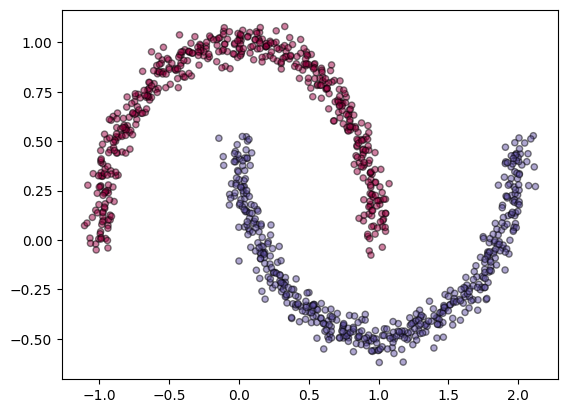

In [6]:
import matplotlib.pyplot as plt
plt.scatter(X[:, 0], X[:, 1], c=y, cmap="Spectral", s=20, edgecolors='k', alpha=0.5)
plt.show()

In [7]:
from sklearn.cluster import KMeans
k = 2
kmeans = KMeans(n_clusters=k, random_state=42)
y_pred = kmeans.fit_predict(X)
print(y_pred)

[1 0 0 0 1 0 0 1 0 1 0 0 0 0 0 0 1 0 0 1 1 1 1 1 1 1 0 0 0 0 1 1 1 1 1 1 0
 1 0 0 1 0 1 0 1 1 0 1 1 0 1 0 1 1 0 0 1 0 1 0 1 0 1 1 1 0 0 0 0 1 0 1 1 0
 1 1 0 0 1 1 0 0 1 0 1 1 0 0 0 1 1 1 1 1 0 1 0 0 0 0 0 1 0 1 0 0 1 0 1 0 1
 0 0 0 0 1 1 0 1 1 0 1 0 1 1 1 1 1 0 0 1 0 1 0 1 0 0 1 0 0 0 1 0 1 0 0 0 1
 0 1 0 1 0 1 0 1 1 0 0 0 1 0 0 0 0 0 1 0 1 1 1 1 0 0 1 1 1 1 0 0 1 0 1 1 0
 1 1 1 0 0 0 0 0 1 1 1 1 1 1 0 0 1 0 1 0 1 1 0 1 0 0 1 0 0 0 1 0 1 0 0 1 0
 0 0 0 0 1 1 0 1 1 0 1 1 0 0 1 0 1 1 0 1 1 0 1 0 1 0 0 1 0 0 0 0 1 1 1 0 0
 0 0 1 0 1 1 0 0 1 0 1 1 0 0 1 1 0 1 1 0 0 1 0 1 1 1 0 1 1 1 0 0 0 1 1 1 1
 0 1 0 1 1 1 1 1 0 0 1 1 0 1 1 1 1 0 1 1 1 1 0 1 0 1 1 0 0 1 1 1 0 0 0 1 0
 0 0 1 0 1 0 1 1 1 1 0 1 1 1 0 0 0 1 1 0 0 1 1 1 1 1 1 1 1 1 1 1 0 0 1 1 0
 1 0 1 1 0 0 1 0 0 0 1 1 0 1 1 0 1 1 0 0 1 0 0 0 1 0 1 1 0 0 0 1 1 1 0 0 0
 1 0 1 1 0 0 1 0 0 0 0 1 1 0 0 1 1 1 1 0 0 0 1 1 1 1 1 1 0 1 1 0 1 1 1 0 0
 1 1 0 1 0 0 1 0 1 1 1 1 0 0 1 1 0 0 1 0 1 0 0 1 1 1 1 0 0 0 1 0 0 0 1 1 1
 0 0 1 1 0 0 1 1 1 0 1 0 

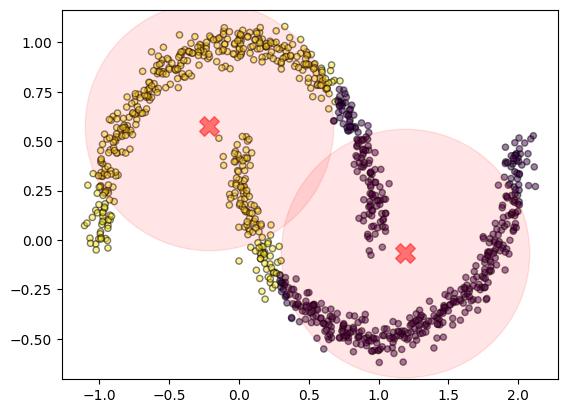

In [18]:
plt.scatter(X[:, 0], X[:, 1], c=y_pred, cmap="viridis", s=20, edgecolors='k', alpha=0.5)
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1],
            c='r', marker='X', s=200, alpha=0.5)
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1],
            c='r', s=32000, alpha=0.1)
plt.show()

# DBSCAN

* Para cada instância, o algoritmo conta quantas instâncias estão
localizadas a uma pequena distância ε (épsilon) dela. Essa região é
chamada de vizinhança ε da instância.

* Se uma instância tiver pelo menos min_samples instâncias em sua vizinhança ε (incluindo ela mesma), então ela é considerada uma instância central.
Em outras palavras, instâncias centrais são aquelas que estão localizadas em regiões densas.

* Todas as instâncias na vizinhança de uma instância central pertencem ao mesmo cluster. Essa vizinhança pode incluir outras instâncias centrais; portanto, uma longa sequência de instâncias centrais vizinhas forma um único cluster.

* Qualquer instância que não seja uma instância central e não tenha uma em sua vizinhança é considerada uma anomalia.

In [24]:
from sklearn.cluster import DBSCAN

dbscan = DBSCAN(eps=0.05, min_samples=5)
y_pred = dbscan.fit_predict(X)
print(y_pred)

[ 0  2 -1 -1  1  0  0  0  2  5  2  3  0  2  2  2  4  2  2  4  0  5  1  0
  5  5  3  2  2  2  4  5  0  6  1 -1  0  0  2  3 -1  3  4 -1  4  4  2  0
  6  2  0  2  4  0  3  3  0  3  5  2 -1  3  0  5  0  0  0  2  3  0  3  6
  0  2  4  4  0  3  0  4  0  3 -1  3  4  0 -1  2  2  4  1  6  0  5  2  6
  2  3  3 -1  2 -1  2  4  0  0  0  2  5  2  0  2 -1  2  3  1  5  2  0  4
  2  1  2  4  4  0  0  6  2  2  0  2 -1  2  0  3  3  5 -1  3  3  5  2  4
  2  2  2  4  2  4  0 -1  2  1  2  6  4  2  3  2 -1  2  0  0  2  0  4  0
  4  4  1  6  3  2  6  1  4  4  2  0  6  0  1  0  2  5  1  1  2  2  2  2
  0  5  5  1  4  5  0  3  3  0  0  0  2  0  5  2 -1  2  3  5  2  2  0  4
  0  4  2  2  4  2  2  3  2  3  0  1  2  0  4 -1  6  0  3  3  5 -1  5  4
  3  5  0  2 -1  3  6  3  3  4  3  2  2  2  1  4  0  2  2 -1  2  6  3  4
  4  2  2  1  0  1  6  3  2  4  0  3  5  0  3  2  0  2  5  4  5  2 -1  6
  5  2  2  2  0  6  1  6  2  1  3  5  0  1 -1  1  2  2  4 -1  2  0  0  0
  0  2  6  6 -1  1  2  5  3  5  4  0  2  0 -1  6  2

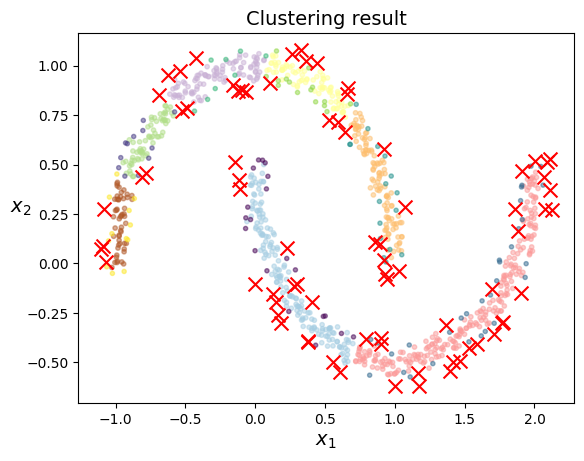

In [37]:
import numpy as np

def plot_dbscan(dbscan, X, size, show_xlabels=True, show_ylabels=True):
  core_mask = np.zeros_like(dbscan.labels_, dtype=bool)
  core_mask[dbscan.core_sample_indices_] = True
  anomalies_mask = dbscan.labels_ == -1
  non_core_mask = ~(core_mask | anomalies_mask)

  cores = dbscan.components_
  anomalies = X[anomalies_mask]
  non_cores = X[non_core_mask]

  plt.scatter(cores[:, 0], cores[:, 1],
              c=dbscan.labels_[core_mask], cmap="Paired",
              s=size, marker='o', alpha=0.5)
  plt.scatter(non_cores[:, 0], non_cores[:, 1],
              c=dbscan.labels_[non_core_mask], marker='.', alpha=0.5)
  plt.scatter(anomalies[:, 0], anomalies[:, 1], c='r', marker='x', s=100)
  if show_xlabels:
    plt.xlabel("$x_1$", fontsize=14)
  else:
    plt.tick_params(labelbottom=False)
  if show_ylabels:
    plt.ylabel("$x_2$", fontsize=14, rotation=0)
  else:
    plt.tick_params(labelleft=False)
  plt.title("Clustering result", fontsize=14)
  plt.show()

plot_dbscan(dbscan, X, size=10)

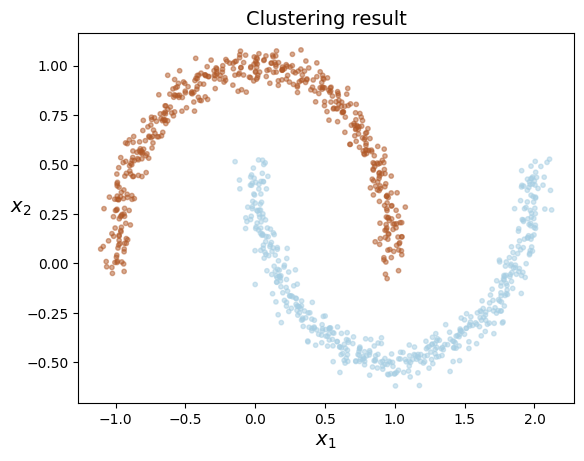

In [38]:
dbscan = DBSCAN(eps=0.2, min_samples=5)
y_pred = dbscan.fit_predict(X)
plot_dbscan(dbscan, X, size=10)

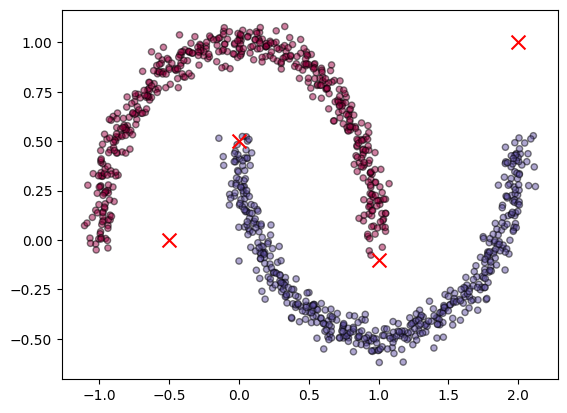

In [41]:
X_new = np.array([[-0.5, 0], [0, 0.5], [1, -0.1], [2, 1]])
plt.scatter(X[:, 0], X[:, 1], c=y, cmap="Spectral", s=20, edgecolors='k', alpha=0.5)
plt.scatter(X_new[:, 0], X_new[:, 1], c='r', marker='x', s=100)
plt.show()

In [45]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=50)
knn.fit(dbscan.components_, dbscan.labels_[dbscan.core_sample_indices_])
print(knn.predict(X_new))

[1 0 1 0]


In [46]:
knn.predict_proba(X_new)

array([[0.18, 0.82],
       [1.  , 0.  ],
       [0.12, 0.88],
       [1.  , 0.  ]])

In [48]:
y_dist, y_pred_idx = knn.kneighbors(X_new, n_neighbors=1)
y_pred = dbscan.labels_[dbscan.core_sample_indices_][y_pred_idx]
y_pred[y_dist > 0.2] = -1
y_pred.ravel()

array([-1,  0,  1, -1])

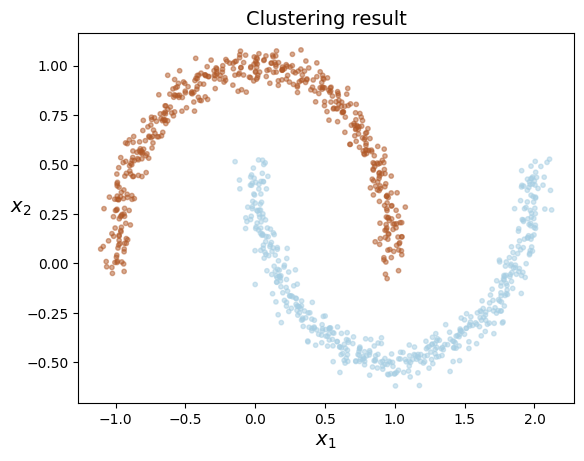

In [53]:
from sklearn.cluster import HDBSCAN

clusterer = HDBSCAN()
y_pred = clusterer.fit_predict(X)
plot_dbscan(dbscan, X, size=10)